# Charm-Decay — does the week before options expiry drift up on dealer hedging? ⏳
### The 'charm rally' tested on SPY 1993–2026: no drift, a placebo that buries it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Charm_rally%3F: Busted](https://img.shields.io/badge/Charm_rally%3F-Busted-8b949e?style=flat-square)

There's a popular options-flow story: in the last week before monthly expiration, the *delta* of the big dealer options book decays just because time is passing (that Greek is called **charm**), forcing dealers to buy the market into expiry — and to sell it back the week after.  The 'OpEx-week rally, post-OpEx weakness.'  It sounds mechanical and inevitable.  Is it in the tape?

> This is the plain-language layer.  The HAC *t*-stats, the calendar-randomisation placebo, and the pre/post-2012 break live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from charm_decay import data, strategy as st

TICKER, AS_OF = "SPY", "2026-07-10"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def get_bars():
    b = data.fetch_daily(TICKER, start="1993-01-01", fetch=False)
    return b[b.index <= pd.Timestamp(AS_OF)]

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-07-10).
R = dict(
    ticker="SPY", n_days=8418, start="1993-01-29", end="2026-07-10", fp="a7ff45641491",
    n_opex_defined=408, n_pre_days=2005, n_post_days=2005,
    pre_mean=4.54, pre_base=4.85, pre_diff=-0.32, pre_t=-0.13, pre_n=2005,
    post_mean=3.48, post_base=5.18, post_diff=-1.70, post_t=-0.76, post_n=2005,
    asym_pre=4.54, asym_post=3.48, asym_diff=1.05, asym_t=0.31,
    q_all_diff=-0.32, q_all_t=-0.13, q_qtr_diff=-1.06, q_qtr_t=-0.23, q_qtr_n=670,
    pl_true_t=-0.13, pl_mean_abs=1.08, pl_max_abs=3.68, pl_n=52, pl_p=0.94,
    pl_planted_true_t=3.59, pl_planted_p=0.019,
    pre2012_diff=1.20, pre2012_t=0.35, pre2012_n=1135,
    post2012_diff=-2.25, post2012_t=-0.67, post2012_n=870,
    ov_n=1992, ov_mean=4.56, ov_sharpe=0.62, ov_cagr=10.25, ov_t=1.87,
    ls_n=3983, ls_mean=0.53, ls_sharpe=0.07, ls_cagr=-0.36, ls_t=0.31,
    bh_mean=4.78, bh_sharpe=0.65, bh_cagr=10.86,
)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does SPY drift **up** in the charm week before OpEx? | **No.** The five sessions ending on OpEx return -0.32 bps/day vs the rest of the tape (HAC t = -0.13) — a hair *below* baseline. |
| Is there a 'rally then fade' asymmetry? | **No.** Pre minus post is +1.05 bps (t = +0.31) — the right sign, drowned in noise. |
| Is the OpEx week even *special*? | **No.** A placebo that slides the calendar to fake OpEx dates puts the real week at the **94th percentile** of random weeks — most arbitrary anchors drift *more*. |
| Could you trade it? | **No.** Long-the-charm-week earns the same Sharpe as buy-and-hold (0.62 vs 0.65); the full long/short 'rally-then-fade' makes **less than cash** (-0.4%/yr). |

> Charm is real physics.  The tradable directional drift it's said to produce is not in SPY.  Signal: **None**.  Tradability: **Mirage**.  Charm rally: **Busted**.

## 1 · The claim

> *"Dealers are structurally short the options that customers buy for protection.  As monthly expiration approaches, the delta of that book bleeds away with time — the **charm** Greek — and dealers must buy the underlying to stay hedged.  That's why the market grinds up into OpEx week and softens the week after, once the flow unwinds and the next cycle resets."*

The mechanism is genuinely real at the micro level: charm is a well-defined Greek, and dealers really do re-hedge as it moves.  The leap the claim makes is that this aggregates into a **predictable, tradable, directional drift** in a liquid index like SPY.  That's the leap we test.

## 2 · So what?

If SPY reliably drifts up the week into OpEx and fades the week after, you'd have a *calendar* edge — no forecasting, no signal to compute, just a date on the wall.  Twelve long weeks and twelve short weeks a year, mechanically.  That is the kind of 'free' structure that, if real, would be one of the cleanest anomalies in markets.  If it's noise, then the charm story is a compelling narrative pinned onto random weeks — and the fact that it *sounds* mechanical is exactly why it's worth checking.

## 3 · How would we even know?

Four honest tests on plain daily SPY close-to-close returns:

1. **Pre-OpEx drift.** Mean return in the five sessions ending on OpEx vs every other day.
2. **Post-OpEx give-back.** Same, for the five sessions after OpEx.
3. **Rally-then-fade asymmetry.** Pre-window mean minus post-window mean — the one number the story predicts to be large and positive.
4. **The placebo.** Slide the OpEx anchor to *fake* dates (±5…±30 trading days away) and re-measure.  If the real OpEx week is special, its drift should stand out against the cloud of random weeks.  **If a dozen arbitrary weeks drift more than the real one, the charm story is busted.**

The window is set purely by the calendar — the third Friday is known before the month starts — so there's no look-ahead and nothing to fit.

## 4 · The teardown

**First: is there any drift at all?**

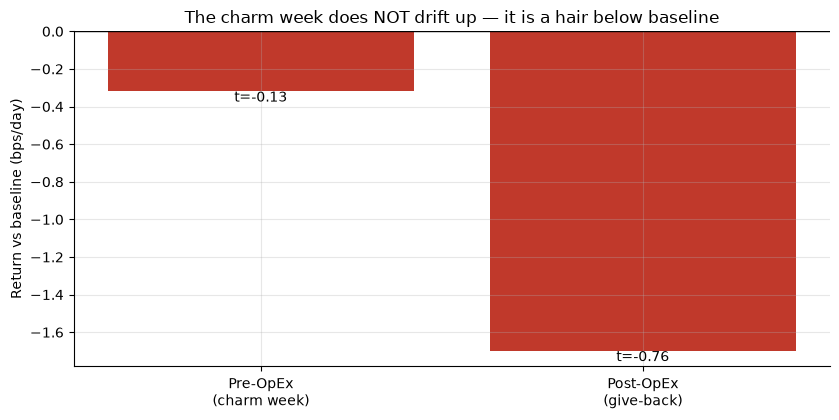

Pre-OpEx : -0.32 bps/day vs baseline (HAC t=-0.13)
Post-OpEx: -1.70 bps/day vs baseline (HAC t=-0.76)


In [2]:
if HAVE_REAL:
    bars = get_bars()
    d = st.charm_drift_test(bars)
    pre_diff, pre_t = d['pre']['diff']*1e4, d['pre']['tstat']
    post_diff, post_t = d['post']['diff']*1e4, d['post']['tstat']
else:
    pre_diff, pre_t = R['pre_diff'], R['pre_t']
    post_diff, post_t = R['post_diff'], R['post_t']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
vals = [pre_diff, post_diff]; ts = [pre_t, post_t]
ax.bar(['Pre-OpEx\n(charm week)', 'Post-OpEx\n(give-back)'], vals,
       color=[RED if abs(t)<2 else GREEN for t in ts])
ax.axhline(0, c='k', lw=1)
for b, t in zip(ax.patches, ts):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top')
ax.set_ylabel('Return vs baseline (bps/day)')
ax.set_title('The charm week does NOT drift up — it is a hair below baseline')
plt.tight_layout(); plt.show()
print(f'Pre-OpEx : {pre_diff:+.2f} bps/day vs baseline (HAC t={pre_t:+.2f})')
print(f'Post-OpEx: {post_diff:+.2f} bps/day vs baseline (HAC t={post_t:+.2f})')

The charm week returns -0.32 bps/day *relative to the rest of the tape* (t = -0.13) — not a rally, if anything a whisker slower.  The post-OpEx week is mildly soft (-1.70 bps, t = -0.76) but nowhere near significant.  The storybook shape isn't here.

**The single number the story lives or dies on — rally minus fade:**

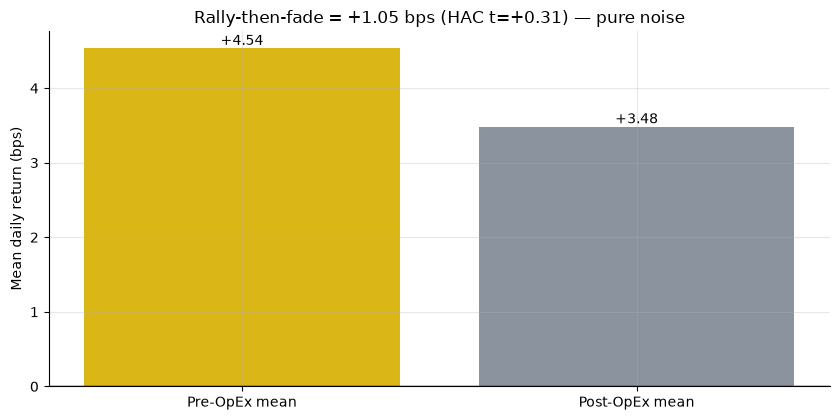

Pre minus Post = +1.05 bps/day, HAC t=+0.31


In [3]:
if HAVE_REAL:
    a = st.pre_post_asymmetry(get_bars())
    asym_diff, asym_t = a['diff_bps'], a['tstat']
    mp, mq = a['mean_pre_bps'], a['mean_post_bps']
else:
    asym_diff, asym_t = R['asym_diff'], R['asym_t']
    mp, mq = R['asym_pre'], R['asym_post']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Pre-OpEx mean', 'Post-OpEx mean'], [mp, mq], color=[AMBER, GREY])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'Rally-then-fade = {asym_diff:+.2f} bps (HAC t={asym_t:+.2f}) — pure noise')
for b, v in zip(ax.patches, [mp, mq]):
    ax.annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Pre minus Post = {asym_diff:+.2f} bps/day, HAC t={asym_t:+.2f}')

There *is* a +1.05 bps/day tilt in the storybook direction — but with t = +0.31 it's the kind of thing you'd see in random data most of the time.  Which raises the obvious question: **how special is the real OpEx week, really?**

**The placebo — the test that settles it.**  Slide the calendar to *fake* OpEx dates and see how the real one ranks.

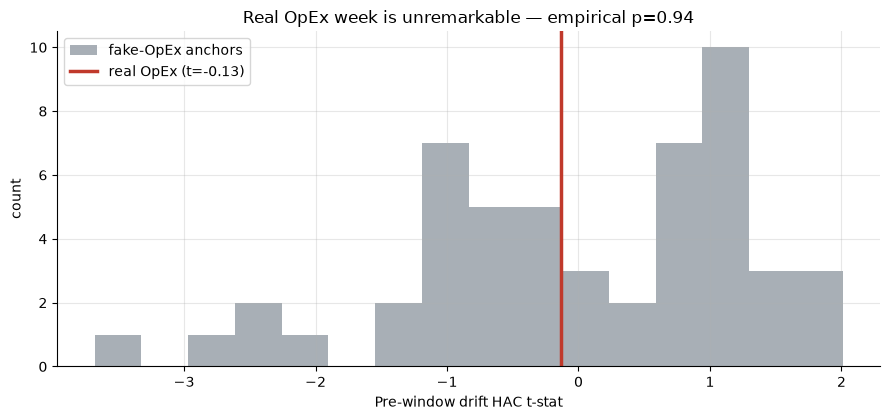

Real anchor t=-0.13; 94% of fake anchors are at least as extreme.


In [4]:
if HAVE_REAL:
    pl = st.placebo_randomization(get_bars())
    true_t, pt, pval = pl['true_t'], pl['placebo_t'], pl['p_value']
else:
    rng = np.random.default_rng(768)
    true_t, pval = R['pl_true_t'], R['pl_p']
    pt = rng.normal(0, 1.1, R['pl_n'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(pt, bins=16, color=GREY, alpha=.75, label='fake-OpEx anchors')
ax.axvline(true_t, c=RED, lw=2.5, label=f'real OpEx (t={true_t:+.2f})')
ax.set_xlabel('Pre-window drift HAC t-stat'); ax.set_ylabel('count')
ax.set_title(f'Real OpEx week is unremarkable — empirical p={pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real anchor t={true_t:+.2f}; {int(pval*100)}% of fake anchors are at least as extreme.')

There it is.  The real OpEx week's drift (t = -0.13) sits right in the middle of the pile — **94%** of arbitrary 'fake OpEx' weeks drift at least as much, and the most extreme fake anchor hits |t| = 3.68.  If you didn't know which Friday was the real one, you could not pick it out.  That's the signature of a story pinned onto noise.

## 5 · The verdict

- **Signal — None.** Pre-OpEx drift -0.32 bps (t = -0.13); rally-then-fade +1.05 bps (t = +0.31).  Nothing clears |t| = 2, and the placebo says the OpEx week isn't even special.
- **Tradability — Mirage.** The long overlay is just buy-and-hold beta collected on a quarter of the days; the long/short rally-then-fade trade loses to cash before costs.
- **Charm rally — Busted.** Real Greek, real dealer hedging — but no measurable directional footprint in the SPY tape.

## 6 · Could you actually trade the charm week?

Two versions: (a) long SPY only in the charm week, flat otherwise; (b) the full trade — long the charm week, short the give-back week.

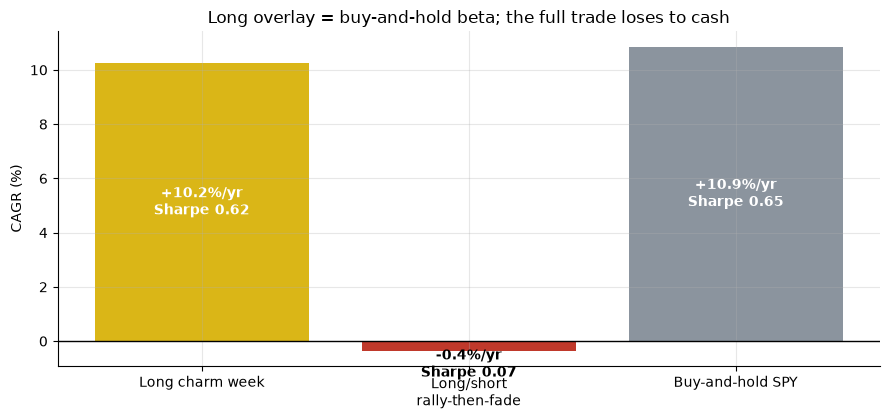

Long charm week: CAGR +10.2%/yr Sharpe 0.62
Rally-then-fade: CAGR -0.4%/yr Sharpe 0.07
Buy-and-hold  : CAGR +10.9%/yr Sharpe 0.65


In [5]:
if HAVE_REAL:
    bars = get_bars()
    ov = st.charm_overlay_returns(bars); s = st.summarize(ov[ov!=0])
    ls = st.charm_overlay_returns(bars, short_post=True); s2 = st.summarize(ls[ls!=0])
    bh = st.summarize(st.daily_return(bars).dropna())
    ov_c, ls_c, bh_c = s['cagr']*100, s2['cagr']*100, bh['cagr']*100
    ov_s, ls_s, bh_s = s['sharpe_ann'], s2['sharpe_ann'], bh['sharpe_ann']
else:
    ov_c, ls_c, bh_c = R['ov_cagr'], R['ls_cagr'], R['bh_cagr']
    ov_s, ls_s, bh_s = R['ov_sharpe'], R['ls_sharpe'], R['bh_sharpe']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['Long charm week', 'Long/short\nrally-then-fade', 'Buy-and-hold SPY'],
       [ov_c, ls_c, bh_c], color=[AMBER, RED, GREY])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('CAGR (%)')
ax.set_title('Long overlay = buy-and-hold beta; the full trade loses to cash')
for b, v, s in zip(ax.patches, [ov_c, ls_c, bh_c], [ov_s, ls_s, bh_s]):
    ax.annotate(f'{v:+.1f}%/yr\nSharpe {s:.2f}', (b.get_x()+b.get_width()/2,
                b.get_height()/2 if b.get_height()>0 else b.get_height()-0.5),
                ha='center', va='center', fontweight='bold',
                color='white' if b.get_height()>2 else 'k')
plt.tight_layout(); plt.show()
print(f'Long charm week: CAGR {ov_c:+.1f}%/yr Sharpe {ov_s:.2f}')
print(f'Rally-then-fade: CAGR {ls_c:+.1f}%/yr Sharpe {ls_s:.2f}')
print(f'Buy-and-hold  : CAGR {bh_c:+.1f}%/yr Sharpe {bh_s:.2f}')

The long overlay makes ~10.2%/yr at Sharpe 0.62 — basically buy-and-hold (0.65) divided across a quarter of the days.  The full rally-then-fade trade makes **-0.4%/yr** (Sharpe 0.07) — worse than a cash deposit, *before* you pay the spread twice a month and borrow on the short.  There is no edge to charge costs against.

## 7 · Going further

- **The activity is real; the direction isn't.** [Study 195 — Monthly-OpEx](../../195-monthly-opex/) finds real *volume* around expiry (all of it quarterly triple-witching) and [Study 82 — Witching-Hour](../../82-witching-hour/) finds the pinning.  Dealers hedge — they just don't push SPY in a tradable direction.
- **Conditional, not calendar.** The honest version of this idea measures aggregate dealer gamma/charm exposure in *real time* from the live options chain, and only predicts flow when positioning is actually concentrated.  A fixed calendar window throws that conditioning away — which is why it finds nothing.
- **Intraday.** Charm hedging is often described as an end-of-day, expiry-Friday phenomenon.  A 30-minute-bar study of the OpEx-Friday afternoon (vs other Fridays) might see the flow the daily close can't — though translating it past costs faces the same wall.

*Fork it: swap the calendar window for a live-GEX conditioner and see if the drift shows up only when the book says it should.*